# 00 - Data Audit (Step 0)

Per-station, per-sensor coverage audit of the raw µEMA CSVs: time range, sampling
gaps, missing-value patterns, and an explicit go/no-go call for this analysis
phase. Every downstream method's results are meaningless without first knowing
which stations have enough clean data to evaluate on — this is done first, on
purpose, rather than discovered later after running a full method comparison.

Outputs (coverage table, station recommendation, timeline figure, and the
written rationale) are saved to `reports/data_audit/` for reuse by later steps.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

from uema.audit import (
    build_coverage_table,
    coverage_segments,
    station_availability,
    station_recommendation,
)
from uema.io import FEATURES, discover_raw_files
from uema.style import PALETTE, apply_style, pretty_label

apply_style()

REPORT_DIR = Path("..") / "reports" / "data_audit"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

## Coverage table

One row per station × sensor: time range, expected vs. actual 10-minute bins,
%missing, gap count, and the largest single gap.

In [2]:
coverage = build_coverage_table()
coverage.to_csv(REPORT_DIR / "coverage_table.csv", index=False)
coverage

,station,feature,start,end,span_days,expected_rows,actual_rows,missing_rows,pct_missing,n_gaps,max_gap
0,recinto-esparza,luminous_intensity,2024-11-21 15:00:00,2026-08-16 00:00:00,632.375000,91063,86293,4770,5.238132,277,3 days 08:10:00
1,recinto-esparza,precipitation,2024-10-27 00:10:00,2026-08-16 00:00:00,657.993056,94752,94752,0,0.000000,0,0 days 00:00:00
2,recinto-esparza,pressure,2024-11-21 15:00:00,2026-08-16 00:00:00,632.375000,91063,86293,4770,5.238132,277,3 days 08:10:00
3,recinto-guapiles,luminous_intensity,2025-04-26 19:10:00,2026-08-04 20:30:00,465.055556,66969,34980,31989,47.766877,56,64 days 06:50:00
4,recinto-guapiles,precipitation,2025-04-25 00:10:00,2026-08-16 00:00:00,477.993056,68832,64512,4320,6.276151,1,30 days 00:10:00
5,recinto-guapiles,pressure,2025-11-19 10:50:00,2025-11-19 13:40:00,0.118056,18,18,0,0.000000,0,0 days 00:00:00
6,recinto-santa-cruz,luminous_intensity,2024-12-12 17:00:00,2026-08-16 00:00:00,611.291667,88027,57565,30462,34.605292,71,42 days 21:00:00
7,recinto-santa-cruz,precipitation,2024-11-26 00:10:00,2026-08-16 00:00:00,627.993056,90432,90432,0,0.000000,0,0 days 00:00:00
8,recinto-santa-cruz,pressure,2024-12-12 17:00:00,2026-08-16 00:00:00,611.291667,88027,57565,30462,34.605292,71,42 days 21:00:00
9,sede-atlantico_turrialba,luminous_intensity,2024-10-03 11:40:00,2026-08-16 00:00:00,681.513889,98139,95259,2880,2.934613,74,3 days 18:40:00


## Operational timeline

For every station, three rows (one per sensor) show actually-present data as
filled segments, with white gaps wherever bins are missing — not just each
sensor's overall start/end.

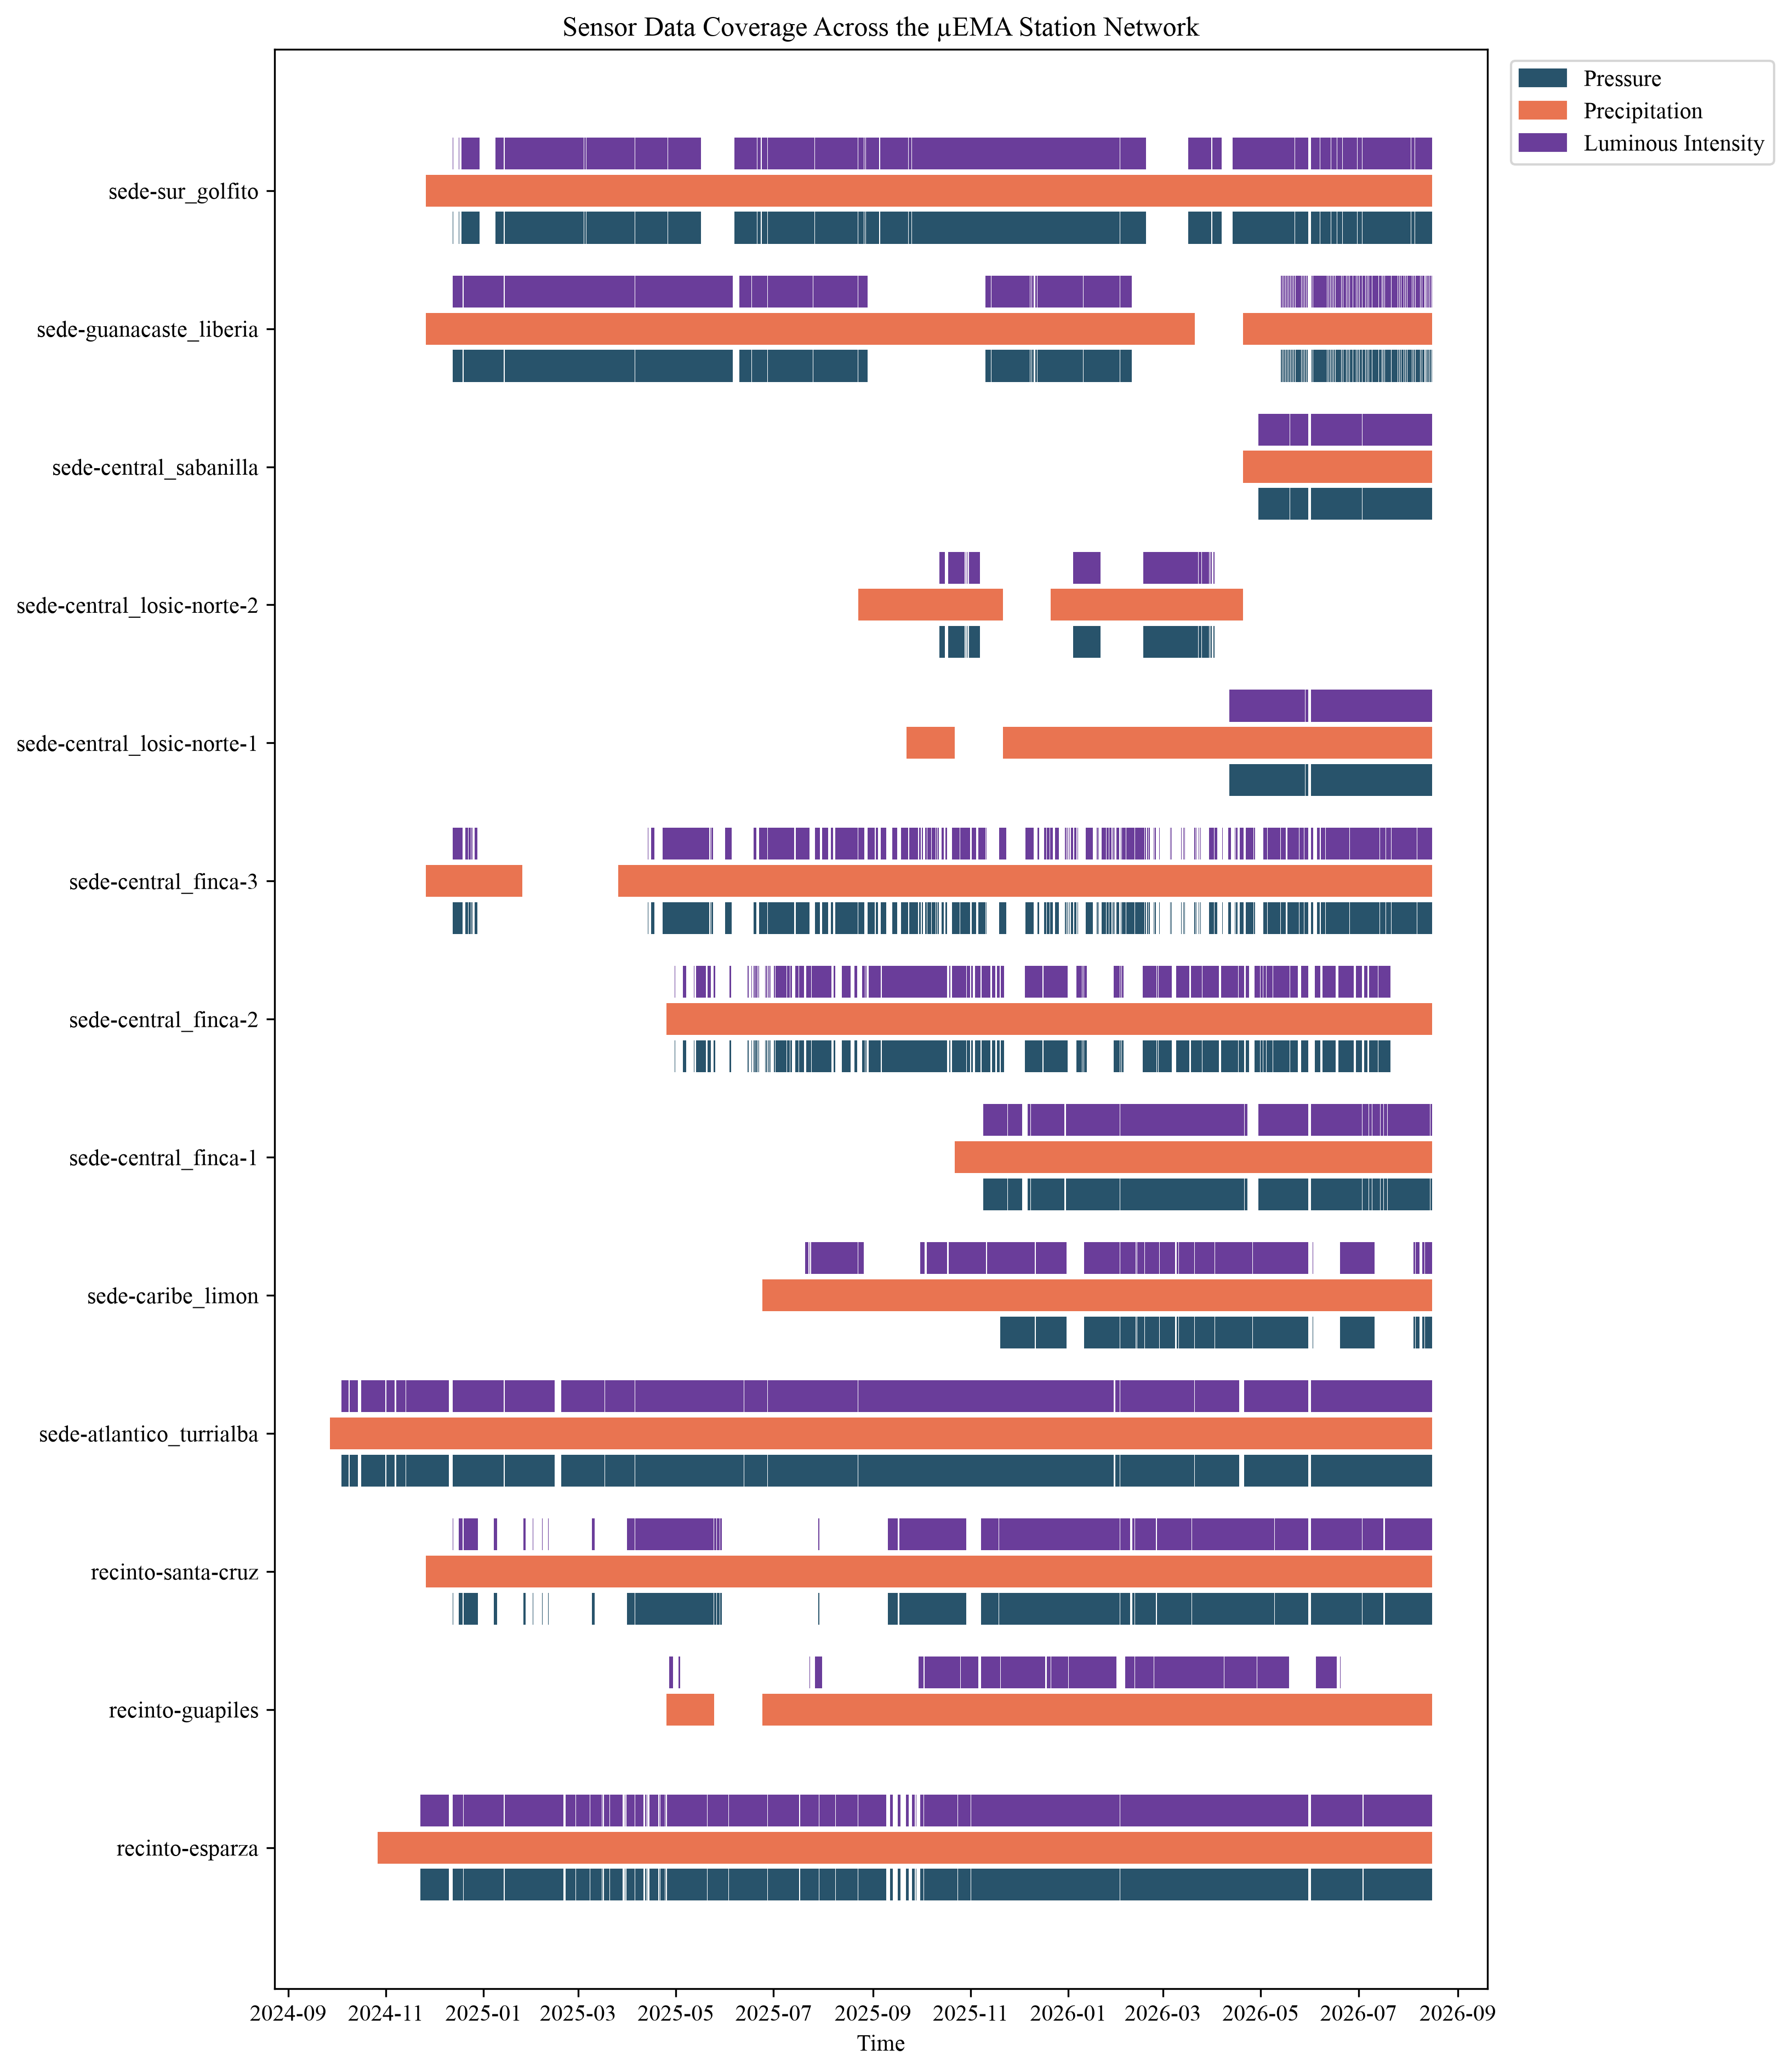

In [3]:
SENSOR_COLORS = {
    "pressure": PALETTE["indigo"],
    "precipitation": PALETTE["burnt_sienna"],
    "luminous_intensity": PALETTE["violet"],
}

raw_files = discover_raw_files()
stations = sorted({f.station for f in raw_files})

row_height = 0.6
sensor_offset = {"pressure": 0.0, "precipitation": 0.7, "luminous_intensity": 1.4}

fig, ax = plt.subplots(figsize=(11, 0.9 * len(stations) + 1))

for station_i, station in enumerate(stations):
    base_y = station_i * 2.6
    for f in [rf for rf in raw_files if rf.station == station]:
        segments = coverage_segments(f)
        bars = [
            (mdates.date2num(start), mdates.date2num(end) - mdates.date2num(start))
            for start, end in segments
        ]
        y = base_y + sensor_offset[f.feature]
        ax.broken_barh(bars, (y, row_height), facecolors=SENSOR_COLORS[f.feature])

ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_yticks([i * 2.6 + 1.0 for i in range(len(stations))])
ax.set_yticklabels(stations)
ax.set_xlabel("Time")
ax.set_title("Sensor Data Coverage Across the µEMA Station Network")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in SENSOR_COLORS.values()]
ax.legend(handles, [pretty_label(s) for s in SENSOR_COLORS], loc="upper left", bbox_to_anchor=(1.01, 1.0))

fig.tight_layout()
fig.savefig(REPORT_DIR / "timeline.png")
plt.show()

## Per-station go/no-go

Explicit, documented decision for this analysis phase — see
`uema.audit.station_recommendation` for the thresholds (90-day minimum joint
window, >25% missing or a single gap >7 days = degraded, >=90% missing =
effectively absent, <30 days of either Costa Rica season = thin-season
caveat) and `reports/data_audit/README.md` for the written rationale.

Sensor tiers are scored on each station's *joint* window — the intersection
of all three sensors' recorded spans — not each sensor's own individual
span, since a sensor with a long but only partially-overlapping history
shouldn't pass a tier it doesn't deserve for joint analysis. `decision` is
the only go/no-go signal: GO (all sensors clean), CONDITIONAL-GO (usable,
but scope around the flagged sensor/season caveats — see `rationale`), or
NO-GO (sensors don't overlap at all, or pressure is absent/too short a
history). No separate "windowed" rescue layer — standard meteorological
practice is to accept a station's actual joint window as-is (interpolating
only short gaps, downstream in `uema.silver.fill_gaps`) rather than
searching for a bespoke optimal clean sub-window per station.

The table also carries `joint_span_start`/`joint_span_end`/`joint_span_days`
for every station — the raw intersection of all three sensors' recorded
spans, with no quality filter applied. This is the exact window
`uema.silver.consolidate_stations` uses for every in-scope (GO or
CONDITIONAL-GO) station.

In [4]:
recommendation = station_recommendation(coverage, raw_files)
recommendation.to_csv(REPORT_DIR / "station_recommendation.csv")
recommendation

,pressure,precipitation,luminous_intensity,decision,rationale,dry_days,wet_days,joint_span_start,joint_span_end,joint_span_days
station,,,,,,,,,,
recinto-esparza,ok,ok,ok,GO,all sensors within coverage thresholds over the joint window,302.0,332.0,2024-11-21 15:00:00,2026-08-16 00:00:00,632.375000
recinto-guapiles,short-history,short-history,short-history,NO-GO,joint sensor overlap under 90 days — insufficient history to use,0.0,1.0,2025-11-19 10:50:00,2025-11-19 13:40:00,0.118056
recinto-santa-cruz,degraded,ok,degraded,CONDITIONAL-GO,"usable with caveats on: pressure, luminous_intensity",291.0,322.0,2024-12-12 17:00:00,2026-08-16 00:00:00,611.291667
sede-atlantico_turrialba,ok,ok,ok,GO,all sensors within coverage thresholds over the joint window,302.0,381.0,2024-10-03 11:40:00,2026-08-16 00:00:00,681.513889
sede-caribe_limon,degraded,ok,degraded,CONDITIONAL-GO,"usable with caveats on: pressure, luminous_intensity",151.0,120.0,2025-11-19 13:10:00,2026-08-16 00:00:00,269.451389
sede-central_finca-1,ok,ok,ok,GO,all sensors within coverage thresholds over the joint window,151.0,131.0,2025-11-08 17:40:00,2026-08-16 00:00:00,280.263889
sede-central_finca-2,degraded,ok,degraded,CONDITIONAL-GO,"usable with caveats on: pressure, luminous_intensity",152.0,296.0,2025-04-30 08:30:00,2026-07-21 15:20:00,447.284722
sede-central_finca-3,degraded,degraded,degraded,CONDITIONAL-GO,"usable with caveats on: pressure, precipitation, luminous_intensity",291.0,322.0,2024-12-12 16:10:00,2026-08-16 00:00:00,611.326389
sede-central_losic-norte-1,ok,ok,ok,CONDITIONAL-GO,"all sensors clean, but thin coverage for season(s): dry (<30d) — caution wit...",24.0,108.0,2026-04-07 19:10:00,2026-08-16 00:00:00,130.201389


In [5]:
recommendation["decision"].value_counts()

decision
CONDITIONAL-GO    9
GO                3
NO-GO             1
Name: count, dtype: int64

## Operational timeline, grouped by decision

Same per-sensor coverage segments as above, but split into three blocks by
`decision`: GO stations, CONDITIONAL-GO stations (usable, with caveats on
the flagged sensor(s)/season — see `rationale`), and NO-GO stations. Each
block is sorted by overall data availability (highest first), so it's easy
to see at a glance how much more/less data the lower tiers actually have
versus the clean ones.

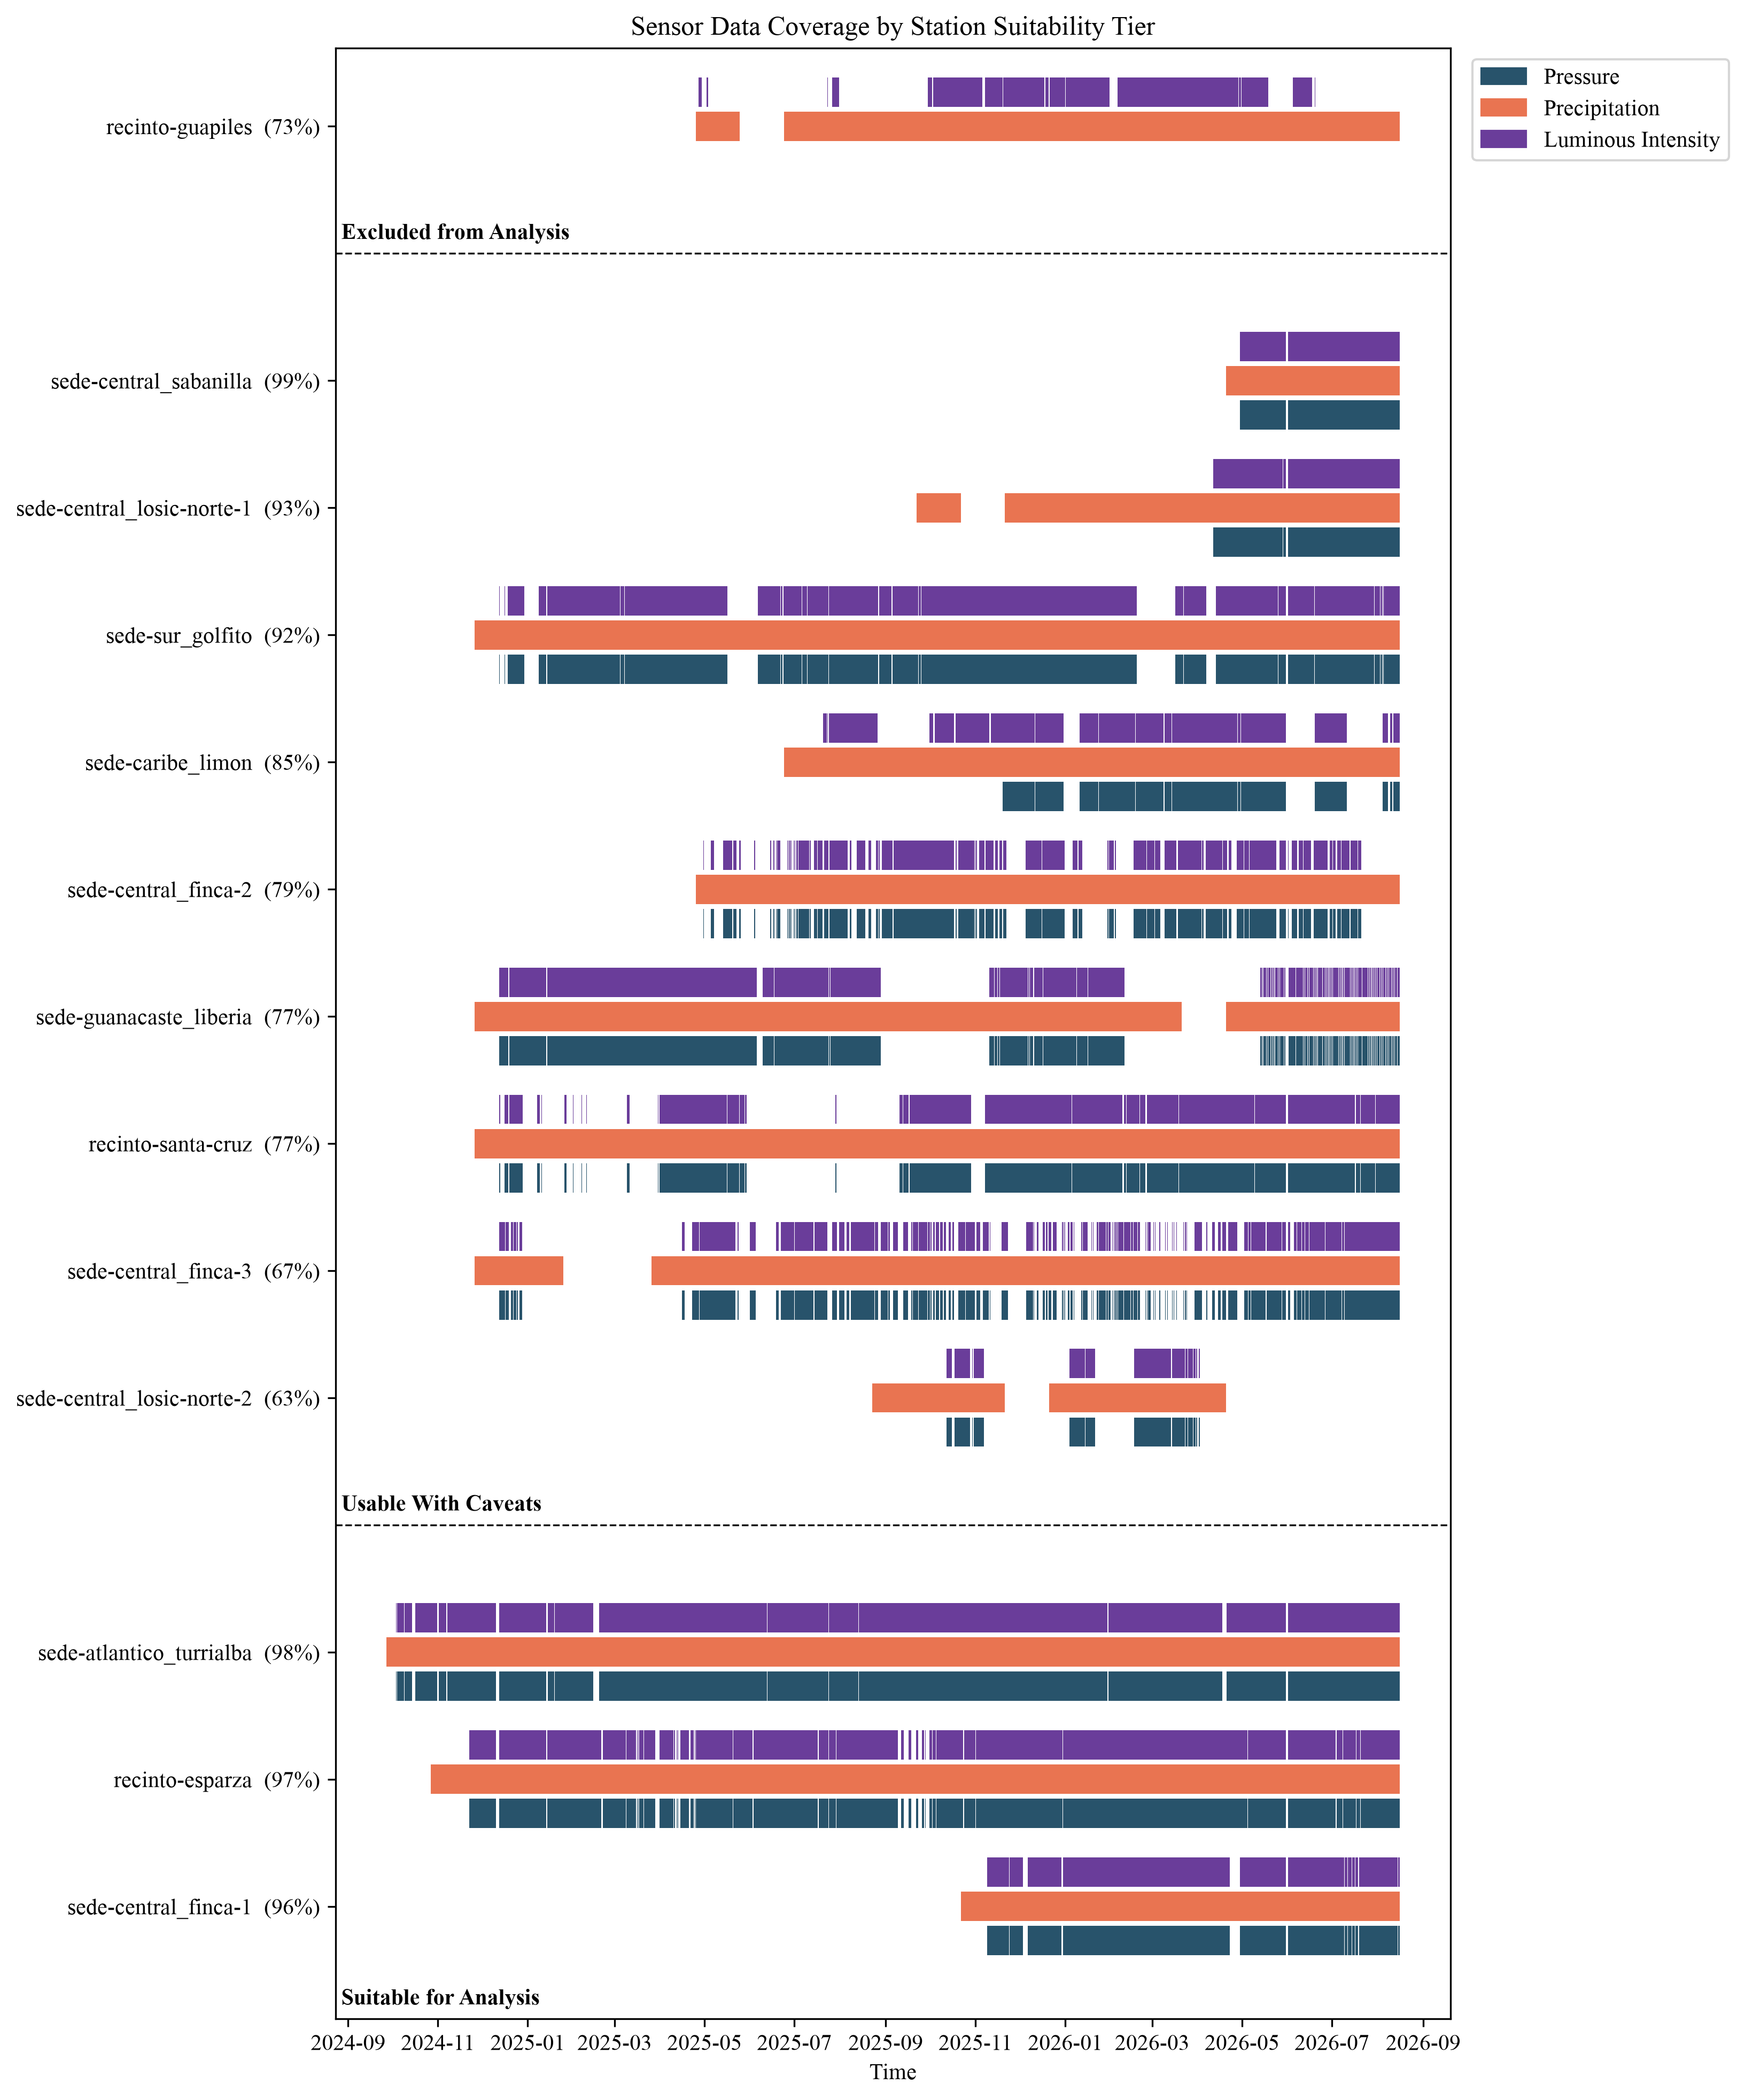

In [6]:
availability = station_availability(coverage)

go_stations = recommendation.index[recommendation["decision"] == "GO"]
conditional_stations = recommendation.index[
    recommendation["decision"] == "CONDITIONAL-GO"
]
nogo_stations = recommendation.index[recommendation["decision"] == "NO-GO"]


# Ascending within each block: since rows are plotted bottom-to-top, the
# highest-availability station in a block ends up nearest its top.
def _sorted_by_availability(stations):
    return availability.loc[stations].sort_values(ascending=True).index.tolist()


go_sorted = _sorted_by_availability(go_stations)
conditional_sorted = _sorted_by_availability(conditional_stations)
nogo_sorted = _sorted_by_availability(nogo_stations)

row_height = 0.6
sensor_offset = {"pressure": 0.0, "precipitation": 0.7, "luminous_intensity": 1.4}
GROUP_GAP = 2.6

# GO block plotted first (bottom of figure), then CONDITIONAL-GO, then NO-GO
# (top) — no placeholder rows in the station list itself, so tick labels
# line up exactly with plotted stations.
y_by_station: dict[str, float] = {}
y = 0.0
for station in go_sorted:
    y_by_station[station] = y
    y += 2.6
divider_1_y = y + GROUP_GAP / 2 - row_height / 2
y += GROUP_GAP
for station in conditional_sorted:
    y_by_station[station] = y
    y += 2.6
divider_2_y = y + GROUP_GAP / 2 - row_height / 2
y += GROUP_GAP
for station in nogo_sorted:
    y_by_station[station] = y
    y += 2.6
top_y = y

ordered_stations = go_sorted + conditional_sorted + nogo_sorted

fig, ax = plt.subplots(figsize=(11, 0.9 * len(ordered_stations) + 1.5))

for station in ordered_stations:
    base_y = y_by_station[station]
    for f in [rf for rf in raw_files if rf.station == station]:
        segments = coverage_segments(f)
        bars = [
            (mdates.date2num(start), mdates.date2num(end) - mdates.date2num(start))
            for start, end in segments
        ]
        y_bar = base_y + sensor_offset[f.feature]
        ax.broken_barh(bars, (y_bar, row_height), facecolors=SENSOR_COLORS[f.feature])

ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_yticks([y_by_station[s] + 1.0 for s in ordered_stations])
ax.set_yticklabels([f"{s}  ({availability[s]:.0%})" for s in ordered_stations])
ax.axhline(divider_1_y, color="black", linewidth=0.8, linestyle="--")
ax.axhline(divider_2_y, color="black", linewidth=0.8, linestyle="--")

# Extra headroom at the very bottom so the "Suitable for Analysis" label has
# room to sit in the bottom-left corner of its panel, mirroring the other
# two panel labels.
bottom_y = -1.3
ax.set_ylim(bottom_y, top_y)

label_kwargs = dict(
    transform=ax.get_yaxis_transform(),
    ha="left",
    va="bottom",
    fontsize=10,
    fontweight="bold",
)
ax.text(0.005, bottom_y + 0.2, "Suitable for Analysis", **label_kwargs)
ax.text(0.005, divider_1_y + 0.2, "Usable With Caveats", **label_kwargs)
ax.text(0.005, divider_2_y + 0.2, "Excluded from Analysis", **label_kwargs)

ax.set_xlabel("Time")
ax.set_title("Sensor Data Coverage by Station Suitability Tier")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in SENSOR_COLORS.values()]
labels = [pretty_label(s) for s in SENSOR_COLORS]
ax.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.01, 1.0))

fig.tight_layout()
fig.savefig(REPORT_DIR / "timeline_grouped.png")
plt.show()